## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✅ Libraries imported successfully
NumPy version: 2.3.4
Pandas version: 2.3.3


## Step 2: Define Database Schema and Tables

Our simulated database has the following tables:
- `customers` - Customer personal information (SENSITIVE)
- `transactions` - Financial transaction records (SENSITIVE)
- `products` - Product catalog (LOW sensitivity)
- `orders` - Order details (MEDIUM sensitivity)
- `audit_logs` - System audit trail (MEDIUM sensitivity)
- `config` - System configuration (HIGH sensitivity)

In [2]:
# Define database schema
DATABASE_TABLES = {
    'customers': {'sensitivity': 'CRITICAL', 'typical_rows': 50000, 'pii': True},
    'transactions': {'sensitivity': 'CRITICAL', 'typical_rows': 500000, 'pii': True},
    'products': {'sensitivity': 'LOW', 'typical_rows': 5000, 'pii': False},
    'orders': {'sensitivity': 'MEDIUM', 'typical_rows': 100000, 'pii': False},
    'audit_logs': {'sensitivity': 'MEDIUM', 'typical_rows': 1000000, 'pii': False},
    'config': {'sensitivity': 'HIGH', 'typical_rows': 500, 'pii': False}
}

# Query operation types
QUERY_TYPES = ['SELECT', 'INSERT', 'UPDATE', 'DELETE', 'JOIN']

print("📊 Database Schema:")
print("-" * 60)
for table, info in DATABASE_TABLES.items():
    print(f"{table:15} | Sensitivity: {info['sensitivity']:8} | Rows: {info['typical_rows']:>7,}")
print("-" * 60)

📊 Database Schema:
------------------------------------------------------------
customers       | Sensitivity: CRITICAL | Rows:  50,000
transactions    | Sensitivity: CRITICAL | Rows: 500,000
products        | Sensitivity: LOW      | Rows:   5,000
orders          | Sensitivity: MEDIUM   | Rows: 100,000
audit_logs      | Sensitivity: MEDIUM   | Rows: 1,000,000
config          | Sensitivity: HIGH     | Rows:     500
------------------------------------------------------------


## Step 3: Define Admin Behavioral Profiles

Each administrator has unique access patterns:

In [3]:
# Administrator behavioral profiles
ADMIN_PROFILES = {
    'admin_alice': {
        'role': 'Data Analyst',
        'typical_tables': ['customers', 'transactions', 'orders'],  # business data
        'query_distribution': {'SELECT': 0.85, 'JOIN': 0.10, 'UPDATE': 0.03, 'INSERT': 0.01, 'DELETE': 0.01},
        'rows_per_query': (10, 1000),  # normal range
        'queries_per_day': (15, 40),
        'work_hours': (8, 18),  # 8 AM - 6 PM
        'join_complexity': (1, 2),  # simple JOINs
        'where_complexity': (1, 3)  # moderate WHERE clauses
    },
    'admin_bob': {
        'role': 'System Administrator',
        'typical_tables': ['audit_logs', 'config', 'customers', 'transactions'],
        'query_distribution': {'SELECT': 0.50, 'UPDATE': 0.20, 'INSERT': 0.15, 'DELETE': 0.10, 'JOIN': 0.05},
        'rows_per_query': (1, 500),
        'queries_per_day': (20, 60),
        'work_hours': (7, 22),  # extended hours for maintenance
        'join_complexity': (0, 1),
        'where_complexity': (1, 4)
    },
    'admin_charlie': {
        'role': 'Developer',
        'typical_tables': ['products', 'orders', 'customers'],  # testing data
        'query_distribution': {'SELECT': 0.60, 'JOIN': 0.20, 'INSERT': 0.10, 'UPDATE': 0.07, 'DELETE': 0.03},
        'rows_per_query': (1, 200),  # testing small datasets
        'queries_per_day': (10, 30),
        'work_hours': (9, 20),  # flexible developer hours
        'join_complexity': (2, 5),  # complex JOINs for testing
        'where_complexity': (2, 6)
    }
}

print("👥 Administrator Profiles:")
print("=" * 70)
for admin, profile in ADMIN_PROFILES.items():
    print(f"\n{admin} ({profile['role']}):")
    print(f"  Primary Tables: {', '.join(profile['typical_tables'])}")
    print(f"  Queries/Day: {profile['queries_per_day'][0]}-{profile['queries_per_day'][1]}")
    print(f"  Work Hours: {profile['work_hours'][0]}:00 - {profile['work_hours'][1]}:00")
    print(f"  Main Operations: {max(profile['query_distribution'], key=profile['query_distribution'].get)}")

👥 Administrator Profiles:

admin_alice (Data Analyst):
  Primary Tables: customers, transactions, orders
  Queries/Day: 15-40
  Work Hours: 8:00 - 18:00
  Main Operations: SELECT

admin_bob (System Administrator):
  Primary Tables: audit_logs, config, customers, transactions
  Queries/Day: 20-60
  Work Hours: 7:00 - 22:00
  Main Operations: SELECT

admin_charlie (Developer):
  Primary Tables: products, orders, customers
  Queries/Day: 10-30
  Work Hours: 9:00 - 20:00
  Main Operations: SELECT


## Step 4: Generate Normal Baseline Data (2-4 Weeks)

We'll generate 28 days of normal database access logs for training our One-Class SVM models.

In [4]:
def generate_query_log(admin_name, profile, timestamp):
    """
    Generate a single database query log entry.
    
    Returns:
        dict: Query log entry with features
    """
    # Select query type based on distribution
    query_type = np.random.choice(
        list(profile['query_distribution'].keys()),
        p=list(profile['query_distribution'].values())
    )
    
    # Select table (80% from typical tables, 20% from others)
    if np.random.random() < 0.8:
        table = np.random.choice(profile['typical_tables'])
    else:
        table = np.random.choice(list(DATABASE_TABLES.keys()))
    
    # Generate query characteristics
    rows_returned = np.random.randint(*profile['rows_per_query'])
    join_count = np.random.randint(*profile['join_complexity']) if query_type == 'JOIN' else 0
    where_count = np.random.randint(*profile['where_complexity'])
    
    # Execution time (correlated with complexity and rows)
    base_time = 0.1 + (rows_returned / 1000) + (join_count * 0.5) + (where_count * 0.2)
    execution_time = max(0.01, np.random.normal(base_time, base_time * 0.3))
    
    return {
        'timestamp': timestamp,
        'admin': admin_name,
        'query_type': query_type,
        'table': table,
        'rows_returned': rows_returned,
        'join_count': join_count,
        'where_count': where_count,
        'execution_time_sec': round(execution_time, 3),
        'table_sensitivity': DATABASE_TABLES[table]['sensitivity'],
        'is_pii_table': DATABASE_TABLES[table]['pii'],
        'hour_of_day': timestamp.hour,
        'day_of_week': timestamp.weekday(),
        'is_attack': False  # normal data
    }

print("✅ Query log generator function defined")

✅ Query log generator function defined


In [5]:
def generate_baseline_data(days=28):
    """
    Generate baseline normal database access logs.
    
    Args:
        days: Number of days to simulate
    
    Returns:
        pd.DataFrame: Baseline query logs
    """
    logs = []
    start_date = datetime(2024, 1, 1, 0, 0, 0)
    
    for day in range(days):
        current_date = start_date + timedelta(days=day)
        
        # Skip weekends (reduce activity)
        is_weekend = current_date.weekday() >= 5
        
        for admin_name, profile in ADMIN_PROFILES.items():
            # Determine number of queries for this day
            queries_today = np.random.randint(*profile['queries_per_day'])
            
            if is_weekend:
                queries_today = int(queries_today * 0.2)  # 20% activity on weekends
            
            # Generate queries during work hours
            for _ in range(queries_today):
                # Random time within work hours
                hour = np.random.randint(*profile['work_hours'])
                minute = np.random.randint(0, 60)
                second = np.random.randint(0, 60)
                
                timestamp = current_date.replace(hour=hour, minute=minute, second=second)
                
                # Generate query log
                log_entry = generate_query_log(admin_name, profile, timestamp)
                logs.append(log_entry)
    
    df = pd.DataFrame(logs)
    df = df.sort_values('timestamp').reset_index(drop=True)
    
    return df

print("⏳ Generating 28 days of baseline data...")
baseline_df = generate_baseline_data(days=28)
print(f"✅ Generated {len(baseline_df):,} baseline query logs")
print(f"\nDataset shape: {baseline_df.shape}")
print(f"Date range: {baseline_df['timestamp'].min()} to {baseline_df['timestamp'].max()}")

⏳ Generating 28 days of baseline data...
✅ Generated 1,913 baseline query logs

Dataset shape: (1913, 13)
Date range: 2024-01-01 07:02:17 to 2024-01-28 21:37:14


## Step 5: Visualize Baseline Patterns

Let's understand the normal behavior before we inject attacks.

In [6]:
# Display sample logs
print("📋 Sample Baseline Logs:")
print("=" * 100)
baseline_df.head(10)

📋 Sample Baseline Logs:


,timestamp,admin,query_type,table,rows_returned,join_count,where_count,execution_time_sec,table_sensitivity,is_pii_table,hour_of_day,day_of_week,is_attack
0,2024-01-01 07:02:17,admin_bob,UPDATE,transactions,323,0,2,0.880,CRITICAL,True,7,0,False
1,2024-01-01 07:39:38,admin_bob,DELETE,transactions,441,0,1,0.787,CRITICAL,True,7,0,False
2,2024-01-01 07:55:16,admin_bob,SELECT,orders,54,0,3,0.981,MEDIUM,False,7,0,False
3,2024-01-01 08:00:47,admin_bob,JOIN,transactions,9,0,1,0.429,CRITICAL,True,8,0,False
4,2024-01-01 08:00:56,admin_alice,SELECT,customers,754,0,1,1.056,CRITICAL,True,8,0,False
5,2024-01-01 08:24:06,admin_alice,SELECT,orders,148,0,1,0.587,MEDIUM,False,8,0,False
6,2024-01-01 08:34:36,admin_alice,UPDATE,audit_logs,227,0,1,0.574,MEDIUM,False,8,0,False
7,2024-01-01 08:58:04,admin_alice,JOIN,orders,210,1,2,1.548,MEDIUM,False,8,0,False
8,2024-01-01 09:00:20,admin_bob,SELECT,customers,197,0,3,0.983,CRITICAL,True,9,0,False
9,2024-01-01 09:04:40,admin_charlie,SELECT,customers,78,0,3,0.754,CRITICAL,True,9,0,False


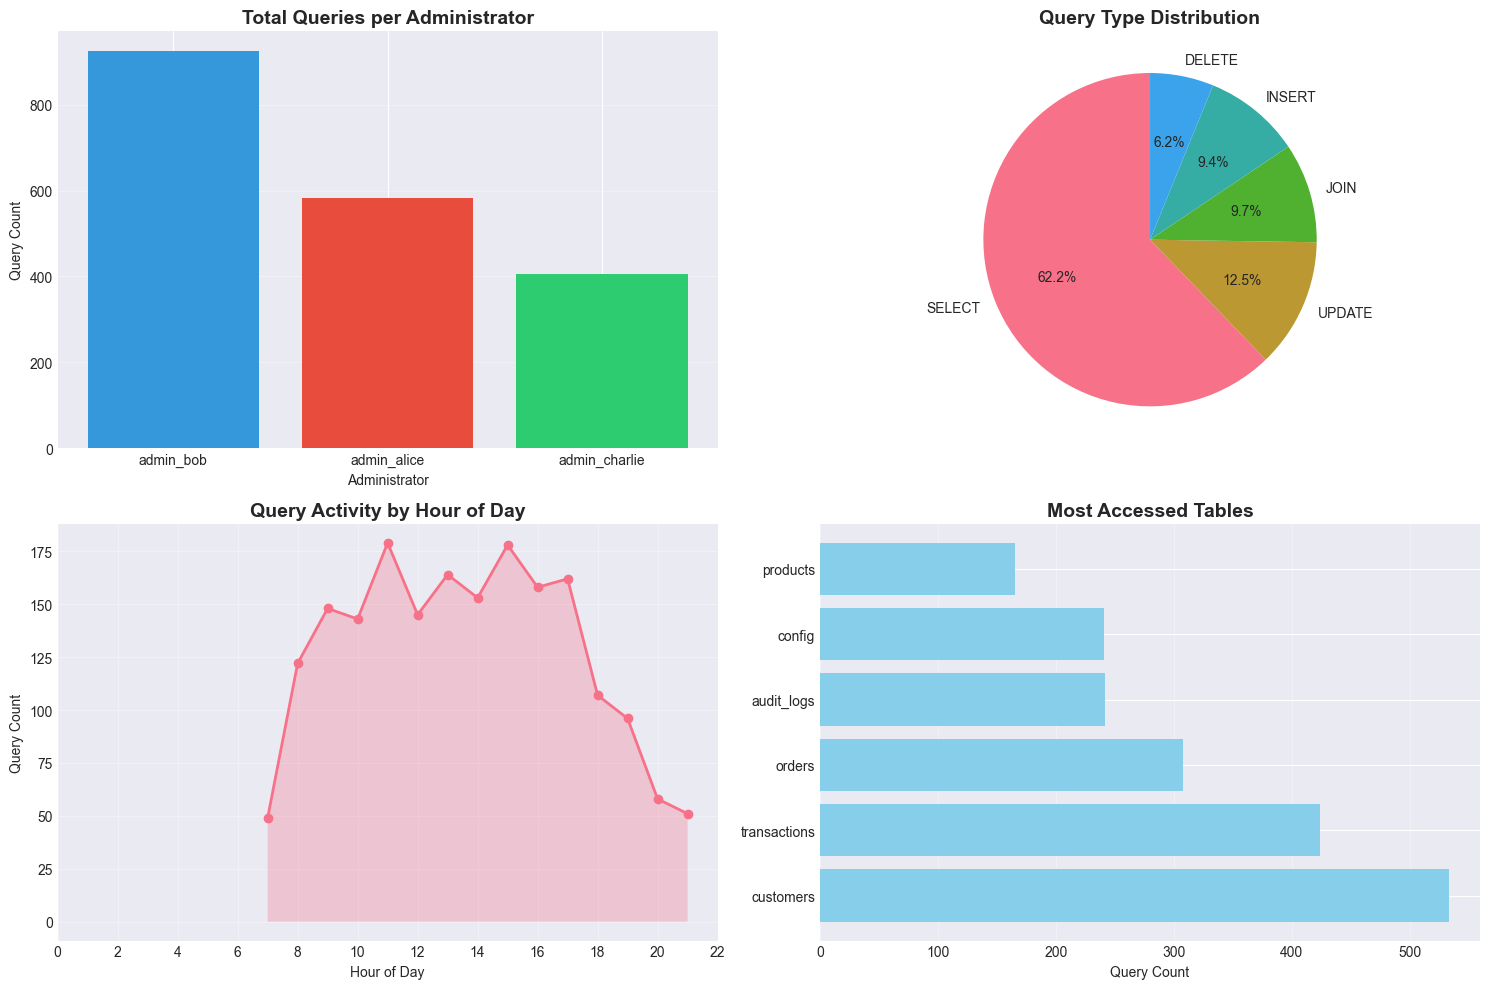

✅ Baseline pattern visualizations saved to results/baseline_patterns.png


In [7]:
# Queries per administrator
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Queries per admin
admin_counts = baseline_df['admin'].value_counts()
axes[0, 0].bar(admin_counts.index, admin_counts.values, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0, 0].set_title('Total Queries per Administrator', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Administrator')
axes[0, 0].set_ylabel('Query Count')
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Query types distribution
query_type_counts = baseline_df['query_type'].value_counts()
axes[0, 1].pie(query_type_counts.values, labels=query_type_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Query Type Distribution', fontsize=14, fontweight='bold')

# Plot 3: Hourly activity
hourly = baseline_df.groupby('hour_of_day').size()
axes[1, 0].plot(hourly.index, hourly.values, marker='o', linewidth=2, markersize=6)
axes[1, 0].fill_between(hourly.index, hourly.values, alpha=0.3)
axes[1, 0].set_title('Query Activity by Hour of Day', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Query Count')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xticks(range(0, 24, 2))

# Plot 4: Table access frequency
table_counts = baseline_df['table'].value_counts().head(6)
axes[1, 1].barh(table_counts.index, table_counts.values, color='skyblue')
axes[1, 1].set_title('Most Accessed Tables', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Query Count')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('results/baseline_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Baseline pattern visualizations saved to results/baseline_patterns.png")

In [8]:
# Per-admin statistics
print("\n📊 Per-Administrator Statistics:")
print("=" * 100)

for admin in baseline_df['admin'].unique():
    admin_data = baseline_df[baseline_df['admin'] == admin]
    print(f"\n{admin}:")
    print(f"  Total queries: {len(admin_data)}")
    print(f"  Avg queries/day: {len(admin_data) / 28:.1f}")
    print(f"  Most common query type: {admin_data['query_type'].mode()[0]}")
    print(f"  Most accessed table: {admin_data['table'].mode()[0]}")
    print(f"  Avg rows returned: {admin_data['rows_returned'].mean():.1f}")
    print(f"  Avg execution time: {admin_data['execution_time_sec'].mean():.3f}s")
    print(f"  Work hour range: {admin_data['hour_of_day'].min()}:00 - {admin_data['hour_of_day'].max()}:00")


📊 Per-Administrator Statistics:

admin_bob:
  Total queries: 925
  Avg queries/day: 33.0
  Most common query type: SELECT
  Most accessed table: customers
  Avg rows returned: 248.3
  Avg execution time: 0.744s
  Work hour range: 7:00 - 21:00

admin_alice:
  Total queries: 583
  Avg queries/day: 20.8
  Most common query type: SELECT
  Most accessed table: transactions
  Avg rows returned: 518.6
  Avg execution time: 0.968s
  Work hour range: 8:00 - 17:00

admin_charlie:
  Total queries: 405
  Avg queries/day: 14.5
  Most common query type: SELECT
  Most accessed table: customers
  Avg rows returned: 95.8
  Avg execution time: 1.170s
  Work hour range: 9:00 - 19:00


## Step 6: Generate Attack Scenarios

Now let's inject three types of attacks:
1. **Reconnaissance**: Attacker probes database with SELECT * queries
2. **Mass Extraction**: Large-scale data theft (10× normal rows)
3. **Credential Theft**: Unusual time/pattern indicating compromised account

In [9]:
def generate_attack_reconnaissance(admin_name, attack_date, num_queries=15):
    """
    Generate reconnaissance attack: attacker explores database structure.
    Characteristics:
    - SELECT * queries (no WHERE clauses)
    - Accesses sensitive tables never accessed before
    - Rapid succession of queries
    """
    attack_logs = []
    
    # Attacker systematically queries all tables
    for i, table in enumerate(DATABASE_TABLES.keys()):
        if i >= num_queries:
            break
        
        timestamp = attack_date + timedelta(minutes=i*2)  # queries every 2 minutes
        
        attack_logs.append({
            'timestamp': timestamp,
            'admin': admin_name,
            'query_type': 'SELECT',
            'table': table,
            'rows_returned': DATABASE_TABLES[table]['typical_rows'],  # SELECT *
            'join_count': 0,
            'where_count': 0,  # NO WHERE clause (suspicious!)
            'execution_time_sec': round(np.random.uniform(2.0, 5.0), 3),
            'table_sensitivity': DATABASE_TABLES[table]['sensitivity'],
            'is_pii_table': DATABASE_TABLES[table]['pii'],
            'hour_of_day': timestamp.hour,
            'day_of_week': timestamp.weekday(),
            'is_attack': True,
            'attack_type': 'reconnaissance'
        })
    
    return attack_logs

def generate_attack_mass_extraction(admin_name, attack_date, target_table='customers'):
    """
    Generate mass data extraction: attacker steals large volume of data.
    Characteristics:
    - Queries return 10-20× normal row counts
    - Targets sensitive PII tables
    - Multiple large queries in short time
    """
    attack_logs = []
    profile = ADMIN_PROFILES[admin_name]
    
    for i in range(8):  # 8 large extraction queries
        timestamp = attack_date + timedelta(minutes=i*5)
        
        # 10-20× normal rows
        normal_max = profile['rows_per_query'][1]
        rows_returned = np.random.randint(normal_max * 10, normal_max * 20)
        
        attack_logs.append({
            'timestamp': timestamp,
            'admin': admin_name,
            'query_type': 'SELECT',
            'table': target_table,
            'rows_returned': rows_returned,
            'join_count': 0,
            'where_count': 1,
            'execution_time_sec': round(np.random.uniform(5.0, 15.0), 3),
            'table_sensitivity': DATABASE_TABLES[target_table]['sensitivity'],
            'is_pii_table': DATABASE_TABLES[target_table]['pii'],
            'hour_of_day': timestamp.hour,
            'day_of_week': timestamp.weekday(),
            'is_attack': True,
            'attack_type': 'mass_extraction'
        })
    
    return attack_logs

def generate_attack_credential_theft(admin_name, attack_date):
    """
    Generate credential theft scenario: attacker using stolen credentials.
    Characteristics:
    - Activity at unusual hours (3 AM)
    - Different query patterns than normal
    - Accesses sensitive data outside normal scope
    """
    attack_logs = []
    profile = ADMIN_PROFILES[admin_name]
    
    # Attack at 3 AM (outside normal work hours)
    attack_time = attack_date.replace(hour=3, minute=0)
    
    for i in range(12):  # 12 queries over 2 hours
        timestamp = attack_time + timedelta(minutes=i*10)
        
        # Access tables this admin doesn't normally use
        unusual_tables = [t for t in DATABASE_TABLES.keys() if t not in profile['typical_tables']]
        table = np.random.choice(unusual_tables)
        
        attack_logs.append({
            'timestamp': timestamp,
            'admin': admin_name,
            'query_type': 'SELECT',
            'table': table,
            'rows_returned': np.random.randint(100, 5000),
            'join_count': 0,
            'where_count': np.random.randint(1, 3),
            'execution_time_sec': round(np.random.uniform(0.5, 3.0), 3),
            'table_sensitivity': DATABASE_TABLES[table]['sensitivity'],
            'is_pii_table': DATABASE_TABLES[table]['pii'],
            'hour_of_day': timestamp.hour,
            'day_of_week': timestamp.weekday(),
            'is_attack': True,
            'attack_type': 'credential_theft'
        })
    
    return attack_logs

print("✅ Attack scenario generators defined")

✅ Attack scenario generators defined


In [10]:
# Generate attack data (day 29-31)
attack_date_base = datetime(2024, 1, 29, 14, 0, 0)

print("🎯 Generating attack scenarios...")

# Attack 1: Alice account - Reconnaissance
attack1 = generate_attack_reconnaissance('admin_alice', attack_date_base, num_queries=12)
print(f"  ✓ Attack 1: Reconnaissance on admin_alice ({len(attack1)} queries)")

# Attack 2: Bob account - Mass Extraction
attack2 = generate_attack_mass_extraction('admin_bob', attack_date_base + timedelta(hours=6), target_table='transactions')
print(f"  ✓ Attack 2: Mass extraction on admin_bob ({len(attack2)} queries)")

# Attack 3: Charlie account - Credential Theft (3 AM activity)
attack3 = generate_attack_credential_theft('admin_charlie', attack_date_base + timedelta(days=1))
print(f"  ✓ Attack 3: Credential theft on admin_charlie ({len(attack3)} queries)")

# Combine all attack data
attack_df = pd.DataFrame(attack1 + attack2 + attack3)
print(f"\n✅ Generated {len(attack_df)} attack query logs")

🎯 Generating attack scenarios...
  ✓ Attack 1: Reconnaissance on admin_alice (6 queries)
  ✓ Attack 2: Mass extraction on admin_bob (8 queries)
  ✓ Attack 3: Credential theft on admin_charlie (12 queries)

✅ Generated 26 attack query logs


## Step 7: Combine and Save Complete Dataset

In [11]:
# Combine baseline and attack data
complete_df = pd.concat([baseline_df, attack_df], ignore_index=True)
complete_df = complete_df.sort_values('timestamp').reset_index(drop=True)

print(f"📊 Complete Dataset Statistics:")
print("=" * 60)
print(f"Total logs: {len(complete_df):,}")
print(f"Normal logs: {len(baseline_df):,} ({len(baseline_df)/len(complete_df)*100:.1f}%)")
print(f"Attack logs: {len(attack_df):,} ({len(attack_df)/len(complete_df)*100:.1f}%)")
print(f"\nDate range: {complete_df['timestamp'].min()} to {complete_df['timestamp'].max()}")
print(f"\nAttack types: {attack_df['attack_type'].value_counts().to_dict()}")

📊 Complete Dataset Statistics:
Total logs: 1,939
Normal logs: 1,913 (98.7%)
Attack logs: 26 (1.3%)

Date range: 2024-01-01 07:02:17 to 2024-01-30 04:50:00

Attack types: {'credential_theft': 12, 'mass_extraction': 8, 'reconnaissance': 6}


In [12]:
# Save datasets
baseline_df.to_csv('data/baseline_logs.csv', index=False)
attack_df.to_csv('data/attack_logs.csv', index=False)
complete_df.to_csv('data/complete_logs.csv', index=False)

print("💾 Datasets saved:")
print("  ✓ data/baseline_logs.csv (training data)")
print("  ✓ data/attack_logs.csv (validation data)")
print("  ✓ data/complete_logs.csv (full dataset)")

# Save summary statistics
summary_stats = {
    'total_logs': len(complete_df),
    'normal_logs': len(baseline_df),
    'attack_logs': len(attack_df),
    'administrators': list(ADMIN_PROFILES.keys()),
    'attack_types': attack_df['attack_type'].unique().tolist(),
    'date_range': {
        'start': str(complete_df['timestamp'].min()),
        'end': str(complete_df['timestamp'].max())
    }
}

import json
with open('data/summary_stats.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)

print("  ✓ data/summary_stats.json (metadata)")

💾 Datasets saved:
  ✓ data/baseline_logs.csv (training data)
  ✓ data/attack_logs.csv (validation data)
  ✓ data/complete_logs.csv (full dataset)
  ✓ data/summary_stats.json (metadata)


## 📝 Summary and Next Steps

### What We Accomplished

✅ **Generated realistic database access logs**:
- 28 days of baseline normal behavior
- 3 administrators with distinct access patterns
- 3 attack scenarios (reconnaissance, mass extraction, credential theft)

✅ **Created training and test datasets**:
- `baseline_logs.csv`: Normal behavior for training One-Class SVM
- `attack_logs.csv`: Attack scenarios for validation
- `complete_logs.csv`: Combined dataset

### Key Observations

1. **Normal patterns are distinct per admin**: Each administrator has unique query distributions, work hours, and table preferences
2. **Attack signatures**:
   - Reconnaissance: SELECT * on all tables, no WHERE clauses
   - Mass extraction: 10-20× normal row counts
   - Credential theft: Unusual hours + atypical table access

### Next Steps → Part 2: Feature Engineering

In the next notebook, we will:
1. Extract behavioral features from these logs
2. Create per-user feature vectors
3. Prepare data for One-Class SVM training

**Continue to**: `Part2_Feature_Engineering.ipynb`

---

**Estimated Time**: ⏱️ 60 minutes  
**Status**: ✅ Phase 1 Complete